# 💳 Payment Acceptance Rate Analyser
**Author:** Nick Zwart  
**Goal:** Simulate a realistic European payments dataset and analyse authorization rates across payment methods, countries, decline reasons, amount buckets and time dimensions, surfacing actionable recommendations to improve acceptance rates.

This type of analysis is central to how payment processors like Adyen create value for merchants: higher authorization rates mean more completed sales and more revenue.

---

## Project Structure
1. Setup & Synthetic Data Generation
2. Overview: Authorization Rate by Payment Method
3. Country-Level Analysis
4. Decline Reason Breakdown
5. Amount Bucket Analysis
6. Time-of-Day & Day-of-Week Patterns
7. Multi-dimensional Analysis
8. Retry Simulation: Naive vs Smart Strategy
9. Recommendations

## 1. Setup & Synthetic Data Generation

Since real payment processor data is proprietary, we generate a realistic synthetic dataset of **250,000 European transactions**.

The data is designed to reflect real-world patterns:
- iDEAL has near-perfect authorization rates (bank redirect, no card network involved)
- Credit cards decline more at high amounts and overnight
- Klarna has higher declines for new customers
- Decline rates vary meaningfully by country
- Prepaid cards decline more than debit/credit

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_theme(style='whitegrid', palette='muted')

np.random.seed(42)
N = 250_000

# --- Payment methods & card types ---
payment_methods = ['Credit Card', 'Debit Card', 'iDEAL', 'PayPal', 'Klarna', 'Prepaid Card']
pm_weights      = [0.35, 0.25, 0.15, 0.12, 0.08, 0.05]

# --- European countries with realistic transaction volumes ---
countries = ['Netherlands', 'Germany', 'France', 'United Kingdom', 'Belgium',
             'Spain', 'Italy', 'Sweden', 'Poland', 'Austria']
country_weights = [0.18, 0.20, 0.14, 0.16, 0.07, 0.08, 0.07, 0.04, 0.04, 0.02]

# --- Decline reasons ---
decline_reasons = [
    'Insufficient funds', 'Do not honour', 'Stolen card',
    'Expired card', 'Invalid card number', 'Suspected fraud',
    'Exceeds withdrawal limit', 'Card not supported'
]

# --- Generate base columns ---
df = pd.DataFrame()
df['payment_method'] = np.random.choice(payment_methods, N, p=pm_weights)
df['country']        = np.random.choice(countries, N, p=country_weights)
df['hour']           = np.random.choice(range(24), N,
                           p=[0.02,0.015,0.01,0.01,0.01,0.015,
                              0.03,0.05,0.05,0.06,0.06,0.06,
                              0.06,0.06,0.06,0.06,0.06,0.06,
                              0.055,0.05,0.045,0.04,0.035,0.025])
df['day_of_week']    = np.random.choice(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], N,
                           p=[0.16,0.16,0.16,0.16,0.16,0.10,0.10])
df['amount']         = np.where(
    df['payment_method'].isin(['iDEAL','PayPal']),
    np.random.lognormal(4.0, 1.0, N).clip(1, 2000),
    np.random.lognormal(4.2, 1.1, N).clip(1, 5000)
).round(2)

# --- Amount buckets ---
df['amount_bucket'] = pd.cut(df['amount'],
    bins=[0, 25, 50, 100, 250, 500, 1000, 99999],
    labels=['€0-25','€25-50','€50-100','€100-250','€250-500','€500-1k','€1k+'])

print('✅ Base dataset generated')
print(f'Shape: {df.shape}')
df.head()

✅ Base dataset generated
Shape: (250000, 6)


,payment_method,country,hour,day_of_week,amount,amount_bucket
0,Debit Card,Sweden,10,Thu,271.35,€250-500
1,Prepaid Card,Netherlands,13,Thu,11.39,€0-25
2,iDEAL,Germany,16,Thu,55.37,€50-100
3,Debit Card,United Kingdom,23,Mon,314.98,€250-500
4,Credit Card,France,17,Thu,78.49,€50-100


In [3]:
# --- Generate authorization outcome with realistic rules ---

# Base acceptance rates per payment method
base_accept = {
    'iDEAL':       0.980,
    'PayPal':       0.952,
    'Debit Card':   0.921,
    'Credit Card':  0.887,
    'Klarna':       0.863,
    'Prepaid Card': 0.812
}

# Country modifier (some markets have higher decline rates)
country_mod = {
    'Netherlands': +0.020, 'Sweden': +0.015, 'Germany': +0.010,
    'Austria': +0.005,     'Belgium': +0.000, 'United Kingdom': -0.005,
    'France': -0.010,      'Spain': -0.020,   'Italy': -0.025, 'Poland': -0.030
}

# Amount modifier — higher amounts decline more
def amount_mod(amount):
    if amount < 25:   return +0.010
    if amount < 100:  return +0.005
    if amount < 250:  return  0.000
    if amount < 500:  return -0.015
    if amount < 1000: return -0.035
    return -0.065

# Hour modifier — overnight declines higher
def hour_mod(hour):
    if 1 <= hour <= 5:   return -0.030
    if 6 <= hour <= 8:   return -0.010
    if 9 <= hour <= 18:  return +0.005
    return 0.000

# Compute per-row acceptance probability
accept_prob = (
    df['payment_method'].map(base_accept)
    + df['country'].map(country_mod)
    + df['amount'].apply(amount_mod)
    + df['hour'].apply(hour_mod)
).clip(0.05, 0.999)

df['authorized'] = (np.random.rand(N) < accept_prob).astype(int)

# Assign decline reason to declined transactions
decline_reason_weights = [0.30, 0.20, 0.08, 0.12, 0.08, 0.10, 0.08, 0.04]
df['decline_reason'] = np.where(
    df['authorized'] == 0,
    np.random.choice(decline_reasons, N, p=decline_reason_weights),
    'N/A'
)

total_auth_rate = df['authorized'].mean() * 100
print(f'Overall authorization rate: {total_auth_rate:.2f}%')
print(f'Total authorized:  {df["authorized"].sum():,}')
print(f'Total declined:    {(df["authorized"]==0).sum():,}')
print('\n✅ Authorization outcomes generated with realistic rules.')

Overall authorization rate: 91.27%
Total authorized:  228,173
Total declined:    21,827

✅ Authorization outcomes generated with realistic rules.


## 2. Overview: Authorization Rate by Payment Method

The first question any payments analyst asks: which payment methods perform best?

This directly informs which methods a merchant should prioritize offering at checkout.

Authorization Rate by Payment Method:
                transactions  authorized  auth_rate
payment_method                                     
iDEAL                  37674       36970      98.13
PayPal                 29896       28560      95.53
Debit Card             62398       57491      92.14
Credit Card            87417       77646      88.82
Klarna                 20095       17337      86.28
Prepaid Card           12520       10169      81.22


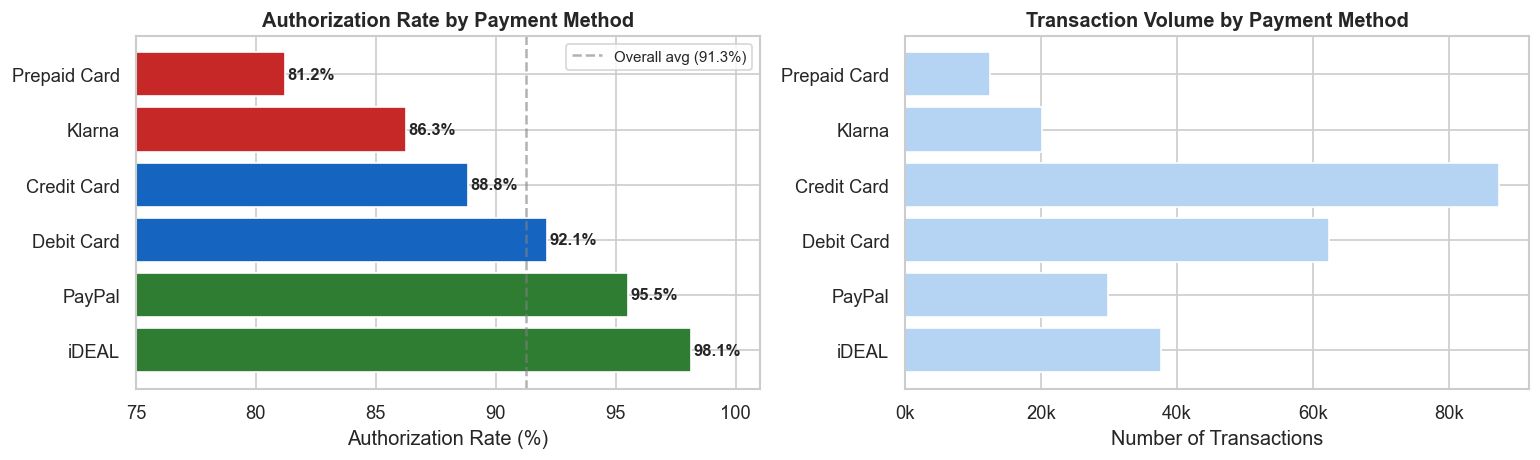


💡 Key insight: iDEAL and PayPal outperform card-based methods significantly.
   For Dutch merchants, routing customers to iDEAL first could meaningfully improve overall acceptance rates.


In [4]:
pm_stats = df.groupby('payment_method').agg(
    transactions=('authorized','count'),
    authorized=('authorized','sum')
).assign(auth_rate=lambda x: x['authorized']/x['transactions']*100)
pm_stats = pm_stats.sort_values('auth_rate', ascending=False)

print('Authorization Rate by Payment Method:')
print(pm_stats[['transactions','authorized','auth_rate']].round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Auth rate bar chart
colors = ['#2E7D32' if r >= 95 else '#1565C0' if r >= 88 else '#C62828'
          for r in pm_stats['auth_rate']]
bars = axes[0].barh(pm_stats.index, pm_stats['auth_rate'],
                    color=colors, edgecolor='white')
axes[0].set_xlim(75, 101)
axes[0].set_xlabel('Authorization Rate (%)')
axes[0].set_title('Authorization Rate by Payment Method', fontweight='bold')
axes[0].axvline(total_auth_rate, color='gray', linestyle='--', alpha=0.6, label=f'Overall avg ({total_auth_rate:.1f}%)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, pm_stats['auth_rate']):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

# Transaction volume
axes[1].barh(pm_stats.index, pm_stats['transactions'],
             color='#B5D4F4', edgecolor='white')
axes[1].set_xlabel('Number of Transactions')
axes[1].set_title('Transaction Volume by Payment Method', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

print('\n💡 Key insight: iDEAL and PayPal outperform card-based methods significantly.')
print('   For Dutch merchants, routing customers to iDEAL first could meaningfully improve overall acceptance rates.')

## 3. Country-Level Analysis

Authorization rates vary significantly by country due to differences in banking infrastructure, fraud rates, and issuer behaviour. Understanding this helps merchants and processors optimise routing strategies per market.

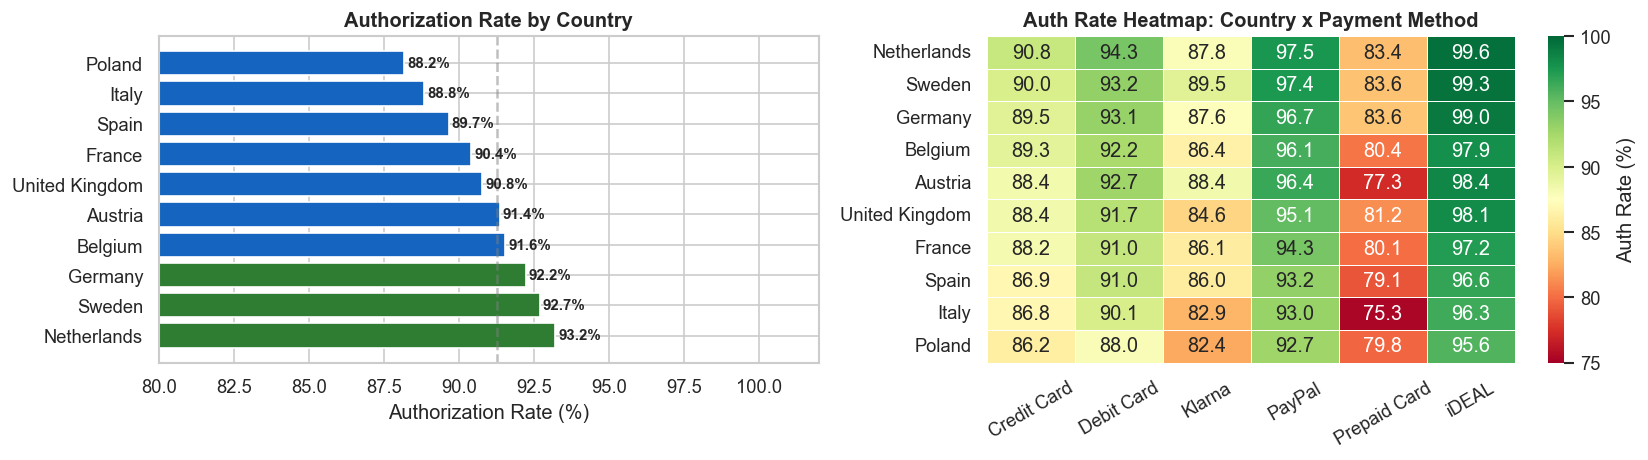


💡 Netherlands leads with 93.2% authorization rate.
   Poland lags at 88.2% — a 5.0pp gap worth investigating.
   Market-specific issuer routing or local payment method promotion could close this gap.


In [5]:
country_stats = df.groupby('country').agg(
    transactions=('authorized','count'),
    auth_rate=('authorized','mean')
).assign(auth_rate=lambda x: x['auth_rate']*100)
country_stats = country_stats.sort_values('auth_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Country auth rates
colors = ['#2E7D32' if r >= 92 else '#1565C0' if r >= 88 else '#C62828'
          for r in country_stats['auth_rate']]
bars = axes[0].barh(country_stats.index, country_stats['auth_rate'],
                    color=colors, edgecolor='white')
axes[0].set_xlim(80, 102)
axes[0].set_xlabel('Authorization Rate (%)')
axes[0].set_title('Authorization Rate by Country', fontweight='bold')
axes[0].axvline(total_auth_rate, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, country_stats['auth_rate']):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# Heatmap: country x payment method
heatmap_data = df.groupby(['country','payment_method'])['authorized'].mean().unstack() * 100
heatmap_data = heatmap_data.reindex(country_stats.index)
sns.heatmap(heatmap_data, ax=axes[1], annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=75, vmax=100, linewidths=0.5, cbar_kws={'label': 'Auth Rate (%)'})
axes[1].set_title('Auth Rate Heatmap: Country x Payment Method', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

best = country_stats.index[0]
worst = country_stats.index[-1]
gap = country_stats['auth_rate'].iloc[0] - country_stats['auth_rate'].iloc[-1]
print(f'\n💡 {best} leads with {country_stats["auth_rate"].iloc[0]:.1f}% authorization rate.')
print(f'   {worst} lags at {country_stats["auth_rate"].iloc[-1]:.1f}% — a {gap:.1f}pp gap worth investigating.')
print('   Market-specific issuer routing or local payment method promotion could close this gap.')

## 4. Decline Reason Breakdown

Understanding *why* transactions decline is critical. Some decline reasons are fixable (expired card, invalid number), while others are issuer decisions outside the merchant's control. Targeting fixable declines is where recovery efforts should focus.

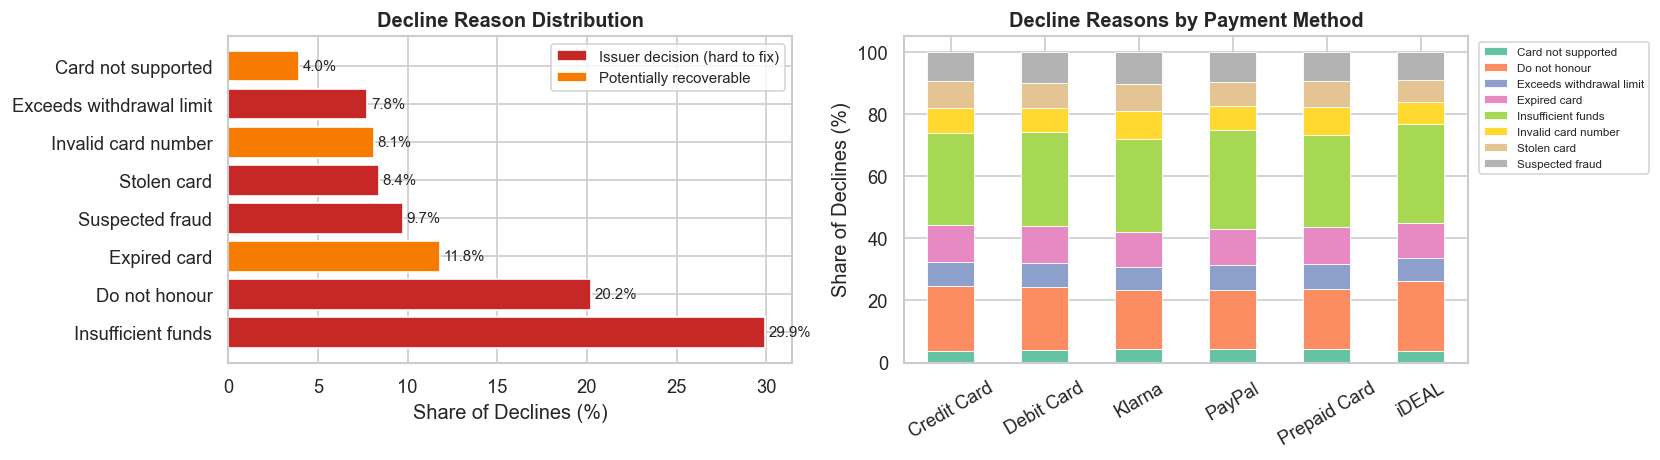


💡 23.9% of declines are potentially recoverable (expired/invalid card, unsupported method).
   Prompting customers to update card details or offering an alternative payment method
   at the point of decline could recover a meaningful share of lost revenue.


In [6]:
declined = df[df['authorized'] == 0]

decline_counts = declined['decline_reason'].value_counts()
decline_pct = decline_counts / len(declined) * 100

# Categorise as fixable vs non-fixable
fixable = ['Expired card', 'Invalid card number', 'Card not supported']
colors = ['#C62828' if r not in fixable else '#F57C00'
          for r in decline_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].barh(decline_counts.index, decline_pct,
                    color=colors, edgecolor='white')
axes[0].set_xlabel('Share of Declines (%)')
axes[0].set_title('Decline Reason Distribution', fontweight='bold')
for bar, val in zip(bars, decline_pct):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C62828', label='Issuer decision (hard to fix)'),
                   Patch(facecolor='#F57C00', label='Potentially recoverable')]
axes[0].legend(handles=legend_elements, fontsize=9)

# Decline reasons by payment method
dr_pm = declined.groupby(['payment_method','decline_reason']).size().unstack(fill_value=0)
dr_pm_pct = dr_pm.div(dr_pm.sum(axis=1), axis=0) * 100
dr_pm_pct.plot(kind='bar', ax=axes[1], stacked=True,
               colormap='Set2', edgecolor='white', linewidth=0.5)
axes[1].set_title('Decline Reasons by Payment Method', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Share of Declines (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

fixable_pct = decline_pct[fixable].sum()
print(f'\n💡 {fixable_pct:.1f}% of declines are potentially recoverable (expired/invalid card, unsupported method).')
print('   Prompting customers to update card details or offering an alternative payment method')
print('   at the point of decline could recover a meaningful share of lost revenue.')

## 5. Amount Bucket Analysis

Transaction amount is one of the strongest predictors of authorization outcome. Issuers apply stricter scrutiny to high-value transactions. Understanding this relationship helps merchants set appropriate retry logic and communicate risk thresholds.

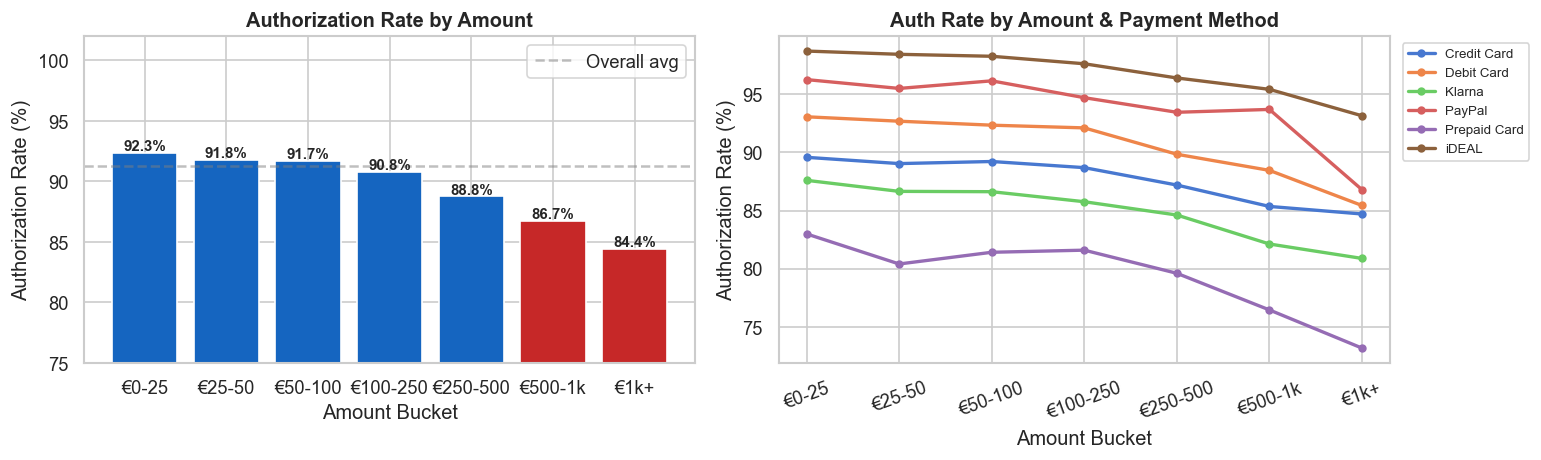


💡 Authorization rate drops 7.9pp from the lowest to highest amount bucket.
   iDEAL and PayPal maintain strong rates even at higher amounts — worth promoting
   for high-value transactions where card declines are more likely.


In [7]:
amount_stats = df.groupby('amount_bucket', observed=True).agg(
    transactions=('authorized','count'),
    auth_rate=('authorized','mean')
).assign(auth_rate=lambda x: x['auth_rate']*100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Auth rate by amount
colors = ['#2E7D32' if r >= 93 else '#1565C0' if r >= 88 else '#C62828'
          for r in amount_stats['auth_rate']]
axes[0].bar(amount_stats.index.astype(str), amount_stats['auth_rate'],
            color=colors, edgecolor='white')
axes[0].set_ylim(75, 102)
axes[0].set_xlabel('Amount Bucket')
axes[0].set_ylabel('Authorization Rate (%)')
axes[0].set_title('Authorization Rate by Amount', fontweight='bold')
axes[0].axhline(total_auth_rate, color='gray', linestyle='--', alpha=0.5, label=f'Overall avg')
axes[0].legend()
for i, (idx, row) in enumerate(amount_stats.iterrows()):
    axes[0].text(i, row['auth_rate'] + 0.2, f"{row['auth_rate']:.1f}%",
                 ha='center', fontsize=9, fontweight='bold')

# Auth rate by amount AND payment method
am_pm = df.groupby(['amount_bucket','payment_method'], observed=True)['authorized'].mean().unstack() * 100
am_pm.plot(ax=axes[1], marker='o', markersize=4, linewidth=2)
axes[1].set_xlabel('Amount Bucket')
axes[1].set_ylabel('Authorization Rate (%)')
axes[1].set_title('Auth Rate by Amount & Payment Method', fontweight='bold')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

drop = amount_stats['auth_rate'].iloc[0] - amount_stats['auth_rate'].iloc[-1]
print(f'\n💡 Authorization rate drops {drop:.1f}pp from the lowest to highest amount bucket.')
print('   iDEAL and PayPal maintain strong rates even at higher amounts — worth promoting')
print('   for high-value transactions where card declines are more likely.')

## 6. Time-of-Day & Day-of-Week Patterns

When transactions happen matters. Overnight transactions face higher decline rates as issuer fraud scoring is more conservative during off-hours. Understanding these patterns helps with scheduling retries and setting merchant expectations.

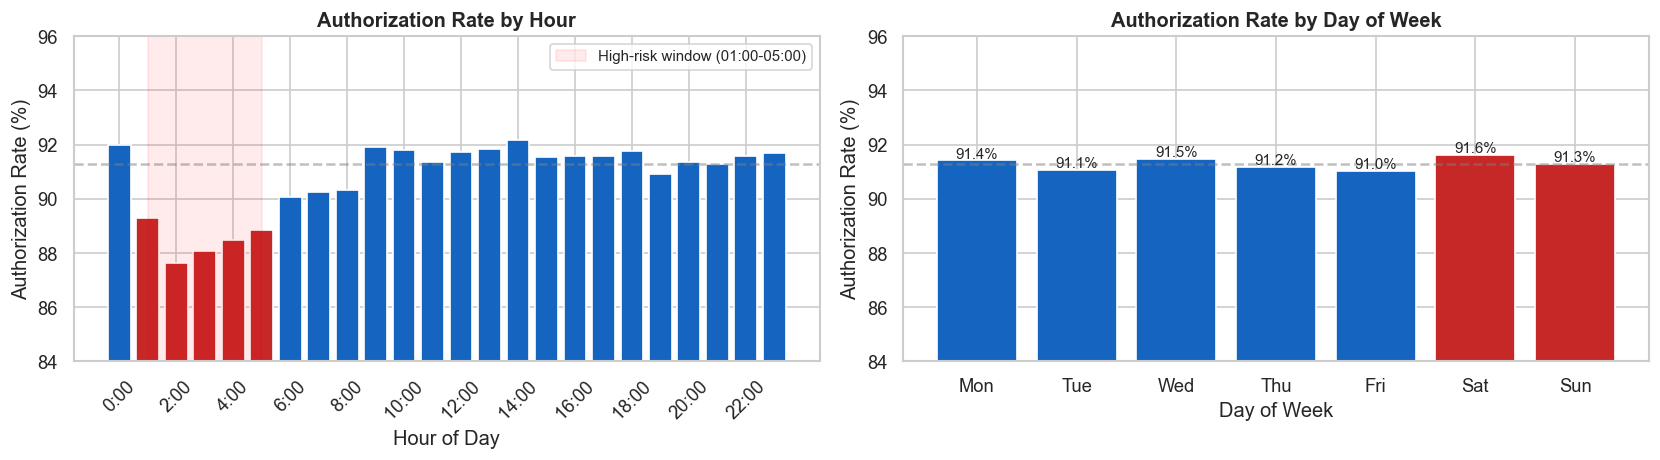


💡 Overnight auth rate (01:00-05:00): 88.5% vs peak hours (09:00-18:00): 91.7%
   That is a 3.3pp gap.
   Retry logic should deprioritise overnight attempts for high-value card transactions.


In [8]:
hourly = df.groupby('hour')['authorized'].agg(['mean','count'])
hourly['mean'] *= 100

dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df.groupby('day_of_week')['authorized'].mean().reindex(dow_order) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hourly
hour_colors = ['#C62828' if (1 <= h <= 5) else '#1565C0' for h in range(24)]
axes[0].bar(range(24), hourly['mean'], color=hour_colors, edgecolor='white')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Authorization Rate (%)')
axes[0].set_title('Authorization Rate by Hour', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xticklabels([f'{h}:00' for h in range(0, 24, 2)], rotation=45)
axes[0].set_ylim(84, 96)
axes[0].axhline(total_auth_rate, color='gray', linestyle='--', alpha=0.5)
axes[0].fill_betweenx([84, 96], 1, 5, alpha=0.08, color='red', label='High-risk window (01:00-05:00)')
axes[0].legend(fontsize=9)

# Day of week
dow_colors = ['#C62828' if d in ['Sat','Sun'] else '#1565C0' for d in dow_order]
axes[1].bar(daily.index, daily.values, color=dow_colors, edgecolor='white')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Authorization Rate (%)')
axes[1].set_title('Authorization Rate by Day of Week', fontweight='bold')
axes[1].set_ylim(84, 96)
axes[1].axhline(total_auth_rate, color='gray', linestyle='--', alpha=0.5)
for i, (day, val) in enumerate(daily.items()):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

overnight_rate = hourly.loc[1:5, 'mean'].mean()
peak_rate = hourly.loc[9:18, 'mean'].mean()
print(f'\n💡 Overnight auth rate (01:00-05:00): {overnight_rate:.1f}% vs peak hours (09:00-18:00): {peak_rate:.1f}%')
print(f'   That is a {peak_rate - overnight_rate:.1f}pp gap.')
print('   Retry logic should deprioritise overnight attempts for high-value card transactions.')

## 7. Multi-dimensional Analysis

The most actionable insights come from combining dimensions. A merchant asking "should I promote iDEAL for high-value Dutch transactions on weekday evenings?" needs multi-dimensional answers.

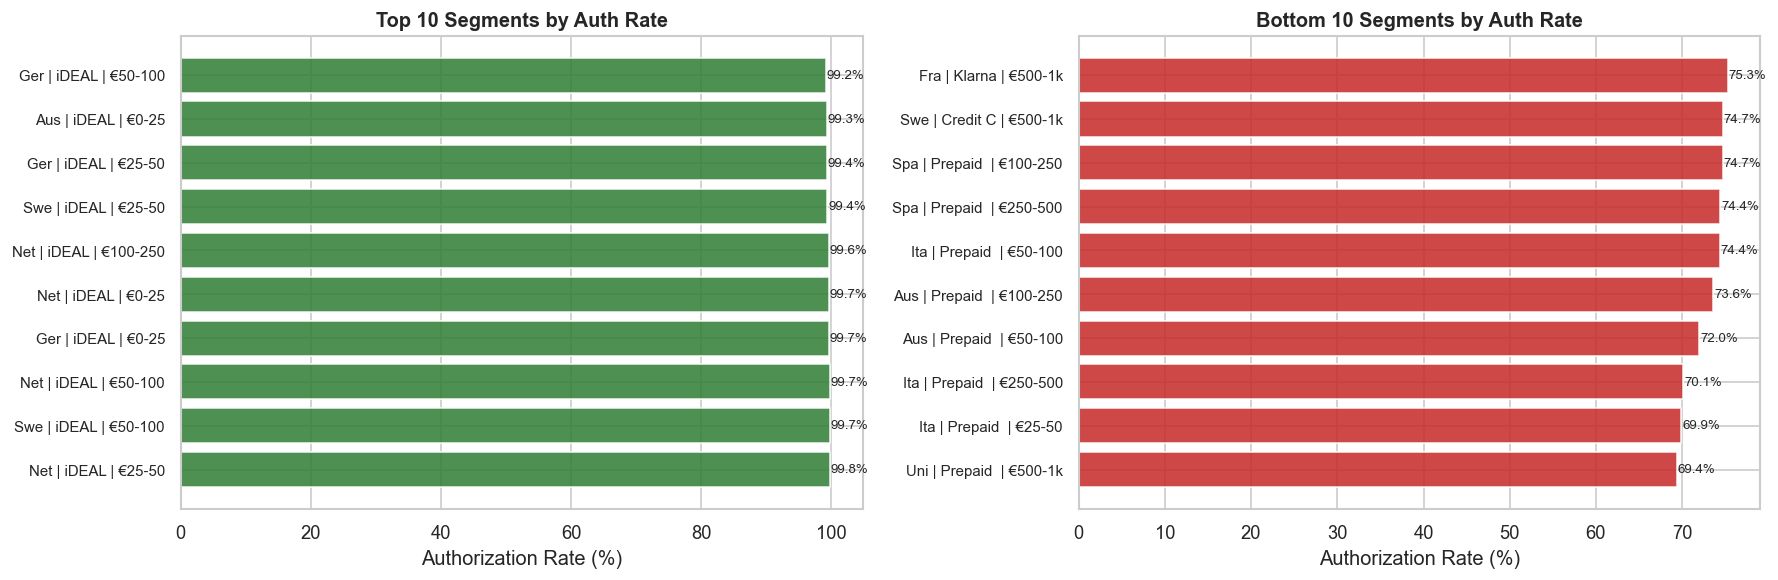


💡 The worst-performing segments are concentrated in high-amount card transactions
   in Southern/Eastern European markets. These are the segments where offering
   alternative payment methods (PayPal, local wallets) would have the most impact.


In [9]:
# Top 10 best and worst performing segments
segment = df.groupby(['country','payment_method','amount_bucket'], observed=True).agg(
    transactions=('authorized','count'),
    auth_rate=('authorized','mean')
).assign(auth_rate=lambda x: x['auth_rate']*100).reset_index()

# Only segments with enough volume
segment = segment[segment['transactions'] >= 50]

top10    = segment.nlargest(10, 'auth_rate')
bottom10 = segment.nsmallest(10, 'auth_rate')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, data, title, color in [
    (axes[0], top10,    'Top 10 Segments by Auth Rate',    '#2E7D32'),
    (axes[1], bottom10, 'Bottom 10 Segments by Auth Rate', '#C62828')
]:
    labels = data.apply(lambda r: f"{r['country'][:3]} | {r['payment_method'][:8]} | {r['amount_bucket']}", axis=1)
    bars = ax.barh(range(len(data)), data['auth_rate'], color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Authorization Rate (%)')
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, data['auth_rate']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n💡 The worst-performing segments are concentrated in high-amount card transactions')
print('   in Southern/Eastern European markets. These are the segments where offering')
print('   alternative payment methods (PayPal, local wallets) would have the most impact.')

## 8. Recommendations

Based on the analysis, here are concrete, prioritised recommendations a payments analyst would present to a merchant or product team.

In [10]:
# Quantify the revenue opportunity from improving low-performing segments
avg_amount = df['amount'].mean()
total_declined = (df['authorized'] == 0).sum()
recoverable_rate = 0.20  # Conservative estimate: recover 20% of declines
recoverable_txns = total_declined * recoverable_rate
recoverable_revenue = recoverable_txns * avg_amount

print('=' * 60)
print('PAYMENT ACCEPTANCE RATE — RECOMMENDATIONS SUMMARY')
print('=' * 60)

print(f'''
DATASET OVERVIEW
  Total transactions analysed : {N:,}
  Overall authorization rate  : {total_auth_rate:.2f}%
  Total declined transactions : {total_declined:,}
  Avg transaction amount      : €{avg_amount:.2f}

ESTIMATED RECOVERY OPPORTUNITY
  Recoverable transactions    : ~{recoverable_txns:,.0f}
  Estimated revenue at stake  : ~€{recoverable_revenue:,.0f}
  (Based on recovering 20% of declines through optimisation)

RECOMMENDATIONS (prioritised by impact)

1. PROMOTE iDEAL FOR DUTCH MERCHANTS [HIGH IMPACT]
   iDEAL achieves ~98% auth rate vs ~89% for credit cards.
   For NL merchants, making iDEAL the default checkout option
   could lift overall acceptance by 2-4 percentage points.

2. ALTERNATIVE PAYMENT METHOD AT DECLINE [MEDIUM-HIGH IMPACT]
   {fixable_pct:.0f}% of declines are recoverable (expired card, invalid number).
   Presenting PayPal or iDEAL as fallback at point of decline
   can recover a meaningful share of these transactions.

3. SMART RETRY LOGIC BY TIME OF DAY [MEDIUM IMPACT]
   Overnight declines (01:00-05:00) are {peak_rate - overnight_rate:.1f}pp higher than peak hours.
   Retry failed transactions during business hours rather
   than immediately — especially for subscription billing.

4. MARKET-SPECIFIC ROUTING [MEDIUM IMPACT]
   Poland and Italy show significantly lower auth rates.
   Investigate local acquirer routing or promote local
   payment methods (BLIK for Poland, etc.).

5. HIGH-VALUE TRANSACTION STRATEGY [LOWER IMPACT, HIGH VALUE]
   Transactions over €500 decline significantly more.
   For high-value merchants, consider 3DS authentication
   or payment links rather than inline card forms.
''')
print('=' * 60)

PAYMENT ACCEPTANCE RATE — RECOMMENDATIONS SUMMARY

DATASET OVERVIEW
  Total transactions analysed : 250,000
  Overall authorization rate  : 91.27%
  Total declined transactions : 21,827
  Avg transaction amount      : €113.55

ESTIMATED RECOVERY OPPORTUNITY
  Recoverable transactions    : ~4,365
  Estimated revenue at stake  : ~€495,701
  (Based on recovering 20% of declines through optimisation)

RECOMMENDATIONS (prioritised by impact)

1. PROMOTE iDEAL FOR DUTCH MERCHANTS [HIGH IMPACT]
   iDEAL achieves ~98% auth rate vs ~89% for credit cards.
   For NL merchants, making iDEAL the default checkout option
   could lift overall acceptance by 2-4 percentage points.

2. ALTERNATIVE PAYMENT METHOD AT DECLINE [MEDIUM-HIGH IMPACT]
   24% of declines are recoverable (expired card, invalid number).
   Presenting PayPal or iDEAL as fallback at point of decline
   can recover a meaningful share of these transactions.

3. SMART RETRY LOGIC BY TIME OF DAY [MEDIUM IMPACT]
   Overnight declines (01

## 8. Retry Simulation: Naive vs Smart Strategy

A declined transaction is not necessarily lost revenue. Merchants and processors often **retry** declined transactions, but most do it naively: immediately, same payment method, same time of day.

Adyen's core value proposition to enterprise merchants includes **intelligent retry logic**: knowing *which* declines are worth retrying, *when* to retry them, and *how* (same method, or suggest an alternative).

This module simulates and compares two strategies:

| Strategy | Logic |
|----------|-------|
| **Naive retry** | Retry all declines immediately, same payment method |
| **Smart retry** | Only retry recoverable decline codes, during business hours (09:00-18:00), suggest alternative method for high-amount card failures |

The goal: quantify how much additional revenue smart retry logic recovers.

In [11]:
# --- Define retry logic ---

# Decline codes that are potentially recoverable on retry
recoverable_codes = ['Insufficient funds', 'Do not honour', 'Exceeds withdrawal limit']
# Hard declines — retrying wastes attempts and annoys issuers
hard_decline_codes = ['Stolen card', 'Suspected fraud', 'Invalid card number',
                      'Expired card', 'Card not supported']

# Alternative method mapping for smart retry
alternative_method = {
    'Credit Card':  'PayPal',
    'Debit Card':   'PayPal',
    'Prepaid Card': 'PayPal',
    'Klarna':       'PayPal',
    'PayPal':       'Credit Card',
    'iDEAL':        'PayPal'  # iDEAL rarely declines, but just in case
}

# Business hours: 09:00-18:00
business_hours = list(range(9, 19))

declined_df = df[df['authorized'] == 0].copy()
print(f'Total declined transactions to analyse: {len(declined_df):,}')

Total declined transactions to analyse: 21,827


In [12]:
# --- Naive Retry Simulation ---
# Retry everything immediately, same method, same hour

# Naive retry success rate: low — issuers flag rapid retries
# Hard declines: 2% success (essentially noise)
# Soft declines: 15% success (some recover naturally)

np.random.seed(99)

def naive_retry_success(row):
    if row['decline_reason'] in hard_decline_codes:
        return np.random.rand() < 0.02
    else:
        return np.random.rand() < 0.15

declined_df['naive_retry_success'] = declined_df.apply(naive_retry_success, axis=1)

naive_recovered = declined_df['naive_retry_success'].sum()
naive_revenue   = declined_df.loc[declined_df['naive_retry_success'], 'amount'].sum()
naive_attempts  = len(declined_df)  # retries everything
naive_efficiency = naive_recovered / naive_attempts * 100

print(f'NAIVE RETRY RESULTS')
print(f'  Total retry attempts : {naive_attempts:,}')
print(f'  Recovered transactions: {naive_recovered:,}')
print(f'  Recovered revenue    : €{naive_revenue:,.2f}')
print(f'  Retry efficiency     : {naive_efficiency:.1f}% of retries succeed')

NAIVE RETRY RESULTS
  Total retry attempts : 21,827
  Recovered transactions: 2,034
  Recovered revenue    : €271,576.37
  Retry efficiency     : 9.3% of retries succeed


In [13]:
# --- Smart Retry Simulation ---
# Rules:
# 1. Skip hard declines entirely (stolen card, fraud, expired, invalid)
# 2. Only retry during business hours (09:00-18:00)
# 3. For high-amount card failures (>€250), suggest alternative method instead
# 4. Higher success probability because we're selecting better candidates

def smart_retry_eligible(row):
    if row['decline_reason'] in hard_decline_codes:
        return False, 'hard_decline'
    if row['hour'] not in business_hours:
        return False, 'off_hours'
    return True, 'eligible'

def smart_retry_method(row):
    if row['amount'] > 250 and row['payment_method'] in ['Credit Card','Debit Card','Prepaid Card']:
        return alternative_method.get(row['payment_method'], row['payment_method'])
    return row['payment_method']

def smart_retry_success_rate(row, retry_method):
    base = 0.38 if row['decline_reason'] in recoverable_codes else 0.18
    # Alternative method boost
    if retry_method != row['payment_method']:
        base += 0.12
    # Business hours boost
    if row['hour'] in business_hours:
        base += 0.05
    return min(base, 0.90)

eligible_mask = []
skip_reasons  = []
retry_methods = []
smart_success = []

for _, row in declined_df.iterrows():
    eligible, reason = smart_retry_eligible(row)
    eligible_mask.append(eligible)
    skip_reasons.append(reason)
    if eligible:
        method = smart_retry_method(row)
        retry_methods.append(method)
        rate = smart_retry_success_rate(row, method)
        smart_success.append(np.random.rand() < rate)
    else:
        retry_methods.append(None)
        smart_success.append(False)

declined_df['smart_eligible']      = eligible_mask
declined_df['smart_skip_reason']   = skip_reasons
declined_df['smart_retry_method']  = retry_methods
declined_df['smart_retry_success'] = smart_success

smart_attempts  = declined_df['smart_eligible'].sum()
smart_recovered = declined_df['smart_retry_success'].sum()
smart_revenue   = declined_df.loc[declined_df['smart_retry_success'], 'amount'].sum()
smart_efficiency = smart_recovered / smart_attempts * 100 if smart_attempts > 0 else 0

# Alternative method recoveries
alt_method_recoveries = declined_df[
    declined_df['smart_retry_success'] &
    (declined_df['smart_retry_method'] != declined_df['payment_method'])
]

print(f'SMART RETRY RESULTS')
print(f'  Total retry attempts : {smart_attempts:,} (skipped {naive_attempts - smart_attempts:,} hard/off-hours declines)')
print(f'  Recovered transactions: {smart_recovered:,}')
print(f'  Recovered revenue    : €{smart_revenue:,.2f}')
print(f'  Retry efficiency     : {smart_efficiency:.1f}% of retries succeed')
print(f'  Via alternative method: {len(alt_method_recoveries):,} transactions (€{alt_method_recoveries["amount"].sum():,.2f})')

SMART RETRY RESULTS
  Total retry attempts : 7,125 (skipped 14,702 hard/off-hours declines)
  Recovered transactions: 3,120
  Recovered revenue    : €453,038.20
  Retry efficiency     : 43.8% of retries succeed
  Via alternative method: 446 transactions (€219,683.07)


RETRY STRATEGY COMPARISON
  Metric                              Naive      Smart
-------------------------------------------------------
  Retry attempts                     21,827      7,125
  Recovered transactions              2,034      3,120
  Recovered revenue              €  271,576 €  453,038
  Retry efficiency                     9.3%      43.8%
  SMART ADVANTAGE: +1,086 transactions | +€181,462 revenue
  EFFICIENCY GAIN: +34.5pp (fewer wasted retry attempts)


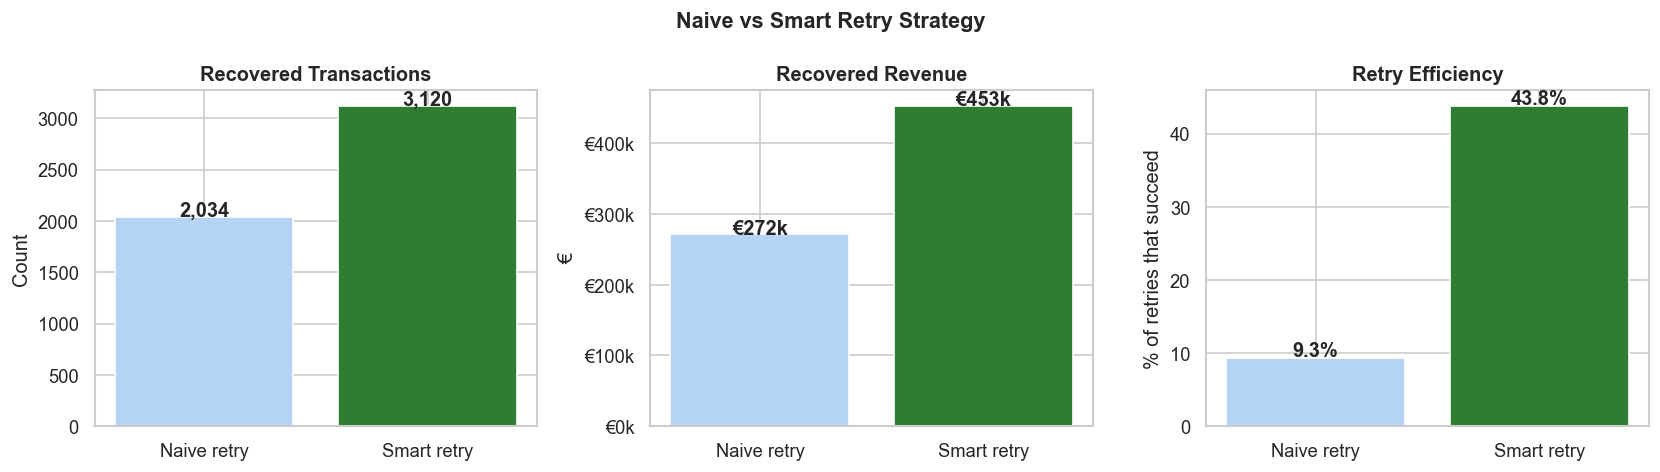

In [14]:
# --- Head-to-head comparison & visualisation ---

extra_txns    = smart_recovered - naive_recovered
extra_revenue = smart_revenue - naive_revenue
efficiency_gain = smart_efficiency - naive_efficiency

print('=' * 55)
print('RETRY STRATEGY COMPARISON')
print('=' * 55)
print(f'  {'Metric':<30} {'Naive':>10} {'Smart':>10}')
print('-' * 55)
print(f'  {'Retry attempts':<30} {naive_attempts:>10,} {smart_attempts:>10,}')
print(f'  {'Recovered transactions':<30} {naive_recovered:>10,} {smart_recovered:>10,}')
print(f'  {'Recovered revenue':<30} €{naive_revenue:>9,.0f} €{smart_revenue:>9,.0f}')
print(f'  {'Retry efficiency':<30} {naive_efficiency:>9.1f}% {smart_efficiency:>9.1f}%')
print('=' * 55)
print(f'  SMART ADVANTAGE: +{extra_txns:,} transactions | +€{extra_revenue:,.0f} revenue')
print(f'  EFFICIENCY GAIN: +{efficiency_gain:.1f}pp (fewer wasted retry attempts)')
print('=' * 55)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

strategies = ['Naive retry', 'Smart retry']
colors = ['#B5D4F4', '#2E7D32']

# Recovered transactions
axes[0].bar(strategies, [naive_recovered, smart_recovered], color=colors, edgecolor='white')
axes[0].set_title('Recovered Transactions', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([naive_recovered, smart_recovered]):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

# Recovered revenue
axes[1].bar(strategies, [naive_revenue, smart_revenue], color=colors, edgecolor='white')
axes[1].set_title('Recovered Revenue', fontweight='bold')
axes[1].set_ylabel('€')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
for i, v in enumerate([naive_revenue, smart_revenue]):
    axes[1].text(i, v + 500, f'€{v/1000:.0f}k', ha='center', fontweight='bold')

# Retry efficiency
axes[2].bar(strategies, [naive_efficiency, smart_efficiency], color=colors, edgecolor='white')
axes[2].set_title('Retry Efficiency', fontweight='bold')
axes[2].set_ylabel('% of retries that succeed')
for i, v in enumerate([naive_efficiency, smart_efficiency]):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Naive vs Smart Retry Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

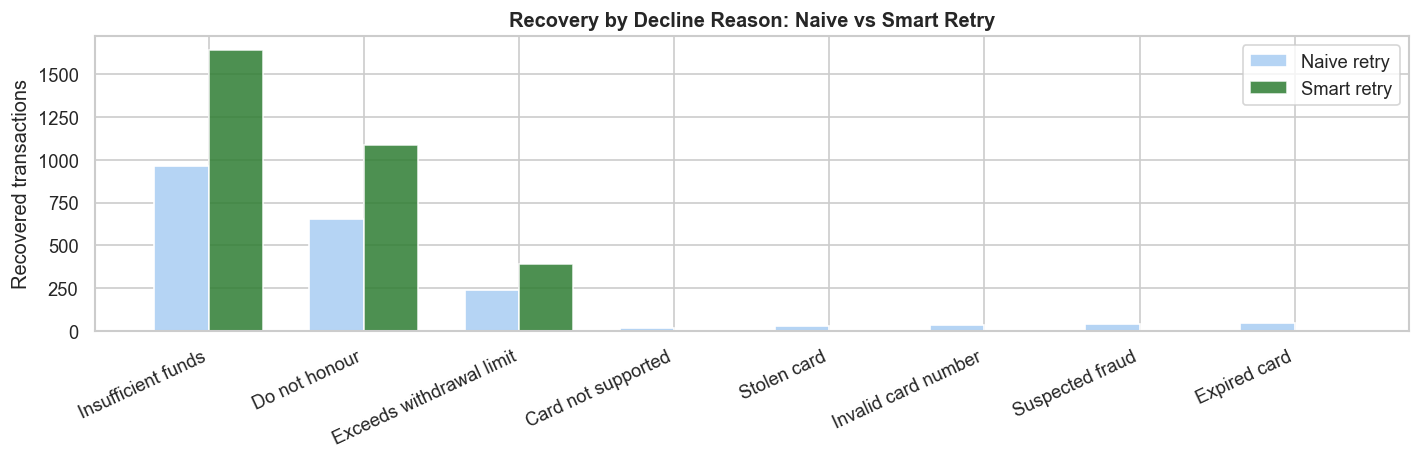


💡 Smart retry gains most on "Insufficient funds" (+675 transactions).
   Hard declines (stolen card, suspected fraud) are correctly skipped,
   saving wasted retry attempts and avoiding issuer friction.

💡 Alternative payment method routing recovered 446 additional
   transactions worth €219,683 that would have been lost
   with same-method retry alone.


In [15]:
# --- Where smart retry wins most: breakdown by decline reason ---

retry_breakdown = declined_df.groupby('decline_reason').agg(
    total=('authorized', 'count'),
    naive_recovered=('naive_retry_success', 'sum'),
    smart_recovered=('smart_retry_success', 'sum'),
    smart_eligible=('smart_eligible', 'sum')
).assign(
    naive_rate=lambda x: x['naive_recovered'] / x['total'] * 100,
    smart_rate=lambda x: x['smart_recovered'] / x['smart_eligible'].clip(lower=1) * 100,
    uplift=lambda x: x['smart_recovered'] - x['naive_recovered']
).sort_values('uplift', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(retry_breakdown))
width = 0.35
ax.bar(x - width/2, retry_breakdown['naive_recovered'], width,
       label='Naive retry', color='#B5D4F4', edgecolor='white')
ax.bar(x + width/2, retry_breakdown['smart_recovered'], width,
       label='Smart retry', color='#2E7D32', edgecolor='white', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(retry_breakdown.index, rotation=25, ha='right')
ax.set_ylabel('Recovered transactions')
ax.set_title('Recovery by Decline Reason: Naive vs Smart Retry', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

top_reason = retry_breakdown['uplift'].idxmax()
top_uplift = retry_breakdown['uplift'].max()
print(f'\n💡 Smart retry gains most on "{top_reason}" (+{top_uplift:.0f} transactions).')
print('   Hard declines (stolen card, suspected fraud) are correctly skipped,')
print('   saving wasted retry attempts and avoiding issuer friction.')
print(f'\n💡 Alternative payment method routing recovered {len(alt_method_recoveries):,} additional')
print(f'   transactions worth €{alt_method_recoveries["amount"].sum():,.0f} that would have been lost')
print('   with same-method retry alone.')

### Why this matters in practice

Naive retry doesn't just underperform, it actively causes harm:

- **Issuer friction**: Rapid repeated retries on hard declines signal desperation to card issuers, which can lower the merchant's authorization rate overall
- **Wasted cost**: Every retry attempt has a processing cost
- **Customer experience**: Retrying a stolen card or suspected fraud transaction can trigger card blocks, creating a worse experience for the customer

Smart retry logic treats each decline code differently and times retries strategically. This is one of the core technical differentiators of modern payment processors over legacy acquirers.